# Structured Data Pipeline — Real-World: Amazon Product Catalog

This notebook replaces the synthetic OHLCV data with the **Amazon Products dataset from Kaggle**,
demonstrating how the same Polars + RAPIDS cuDF structured-data pipeline adapts to real-world
product catalog analytics.

## Dataset
**Source**: Kaggle — `lokeshparab/amazon-products-dataset`  
**Files used**: All per-category CSVs in `DATA_DIR`, or `Amazon-Products.csv` (combined) as fallback  
**Schema**:
| Column | Raw format | Cleaned type |
|--------|-----------|-------------|
| `name` | string | `Utf8` |
| `main_category` | string | `Utf8` |
| `sub_category` | string | `Utf8` |
| `ratings` | `"4.2 out of 5 stars"` or `"4.2"` | `Float32` |
| `no_of_ratings` | `"1,234"` | `Int64` |
| `discount_price` | `"₹12,999"` | `Float64` |
| `actual_price` | `"₹15,999"` | `Float64` |

## How to get the data
```bash
# Option A — Kaggle CLI (recommended)
pip install kaggle
# Place your kaggle.json API key at ~/.kaggle/kaggle.json
kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon

# Option B — Manual download
# Visit the dataset page and download all CSVs, place them in DATA_DIR below.
```

The notebook auto-discovers **all** `.csv` files in `DATA_DIR` and loads them together.
`Amazon-Products.csv` (the pre-combined file) is treated as a single-file fallback if no
individual category CSVs are found.

## Pipeline mapping (synthetic → real)
| Synthetic concept | Amazon Products equivalent |
|-------------------|---------------------------|
| `symbol` | `name` (product title) |
| `asset_class` | `main_category` / source CSV filename |
| `close` price | `discount_price` |
| `open` price | `actual_price` |
| `volume` | `no_of_ratings` |
| price pct change | discount % = `(actual - discount) / actual * 100` |
| aggregate by period | aggregate by `sub_category` |

In [2]:
%load_ext cudf.pandas

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


## Setup

In [ ]:
import logging
import sys
import time
from pathlib import Path

import numpy as np
import polars as pl

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")

# ── Configuration — update DATA_DIR to where you downloaded the Kaggle files ──
DATA_DIR = Path("./data/amazon").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

GPU_DEVICE = 0

# ── Auto-discover all category CSVs ───────────────────────────────────────────
# Exclude the pre-combined file — it will be used only as a fallback.
COMBINED_CSV = DATA_DIR / "Amazon-Products.csv"
SKIP_FILES   = {"Amazon-Products.csv", "Stores.csv"}   # Stores.csv has a different schema

category_csvs = sorted(
    p for p in DATA_DIR.glob("*.csv")
    if p.name not in SKIP_FILES
)

if not category_csvs and not COMBINED_CSV.exists():
    print("\nNo CSV files found — download from Kaggle:")
    print("  kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon")

# GPU check
try:
    _e = pl.GPUEngine(device=GPU_DEVICE, raise_on_fail=True)
    pl.LazyFrame({"x": [1]}).collect(engine=_e)
    GPU_AVAILABLE = True
except Exception as ex:
    GPU_AVAILABLE = False
    print(f"\nGPU: not available ({ex}) — CPU fallback active")

---
## Step 1 — Load and inspect the raw CSVs

Each category file uses the same schema but may have missing values in price/rating columns.
We load all files, tag with the source category, and concatenate into one LazyFrame.

In [ ]:
READ_OPTS = dict(
    infer_schema_length=5000,
    ignore_errors=True,
    null_values=["", "NA", "N/A", "null", "None"],
)

if category_csvs:
    frames = [
        pl.read_csv(p, **READ_OPTS).with_columns(pl.lit(p.stem).alias("source_category"))
        for p in category_csvs
    ]
elif COMBINED_CSV.exists():
    df = pl.read_csv(COMBINED_CSV, **READ_OPTS)
    src = pl.col("main_category") if "main_category" in df.columns else pl.lit("All")
    frames = [df.with_columns(src.alias("source_category"))]
else:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_DIR}.\n"
        "Download from Kaggle:\n"
        "  kaggle datasets download -d lokeshparab/amazon-products-dataset --unzip -p ./data/amazon"
    )

# diagonal_relaxed handles minor schema differences across files
raw_df = pl.concat(frames, how="diagonal_relaxed")

n_cats = raw_df["source_category"].n_unique()


---
## Step 2 — Data cleaning

The raw CSVs encode prices and ratings as messy strings. We clean them with Polars
string expressions — fully vectorized, runs on GPU when available.

**Price columns** (e.g. `₹12,999` or `$129.99`):
- Strip currency symbol (`₹`, `$`, `€`, `£`) and commas
- Cast to `Float64`

**Ratings column** (e.g. `"4.2 out of 5 stars"` or `"4.2"`):
- Extract the leading decimal number
- Cast to `Float32`

**no_of_ratings** (e.g. `"1,234"`):
- Remove commas, cast to `Int64`

In [ ]:
def clean_price(col_name: str) -> pl.Expr:
    """Strip currency symbols and commas, cast to Float64."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.replace_all(r"[₹$€£,\s]", "")
        .str.strip_chars()
        .cast(pl.Float64, strict=False)
        .alias(col_name)
    )


def clean_rating(col_name: str) -> pl.Expr:
    """Extract leading float from strings like '4.2 out of 5 stars'."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.extract(r"^([0-9]+\.?[0-9]*)", 1)
        .cast(pl.Float32, strict=False)
        .alias(col_name)
    )


def clean_rating_count(col_name: str) -> pl.Expr:
    """Remove commas from '1,234' style counts."""
    return (
        pl.col(col_name)
        .cast(pl.Utf8)
        .str.replace_all(",", "")
        .cast(pl.Int64, strict=False)
        .alias(col_name)
    )


# Detect which price/rating columns exist in the data
cols = set(raw_df.columns)
price_cols  = [c for c in ["discount_price", "actual_price"] if c in cols]
rating_col  = "ratings" if "ratings" in cols else None
count_col   = "no_of_ratings" if "no_of_ratings" in cols else None

clean_exprs = [clean_price(c) for c in price_cols]
if rating_col:
    clean_exprs.append(clean_rating(rating_col))
if count_col:
    clean_exprs.append(clean_rating_count(count_col))

products = raw_df.with_columns(clean_exprs)

# Derived columns — mirrors what OHLCV pipeline computes from price data
if "discount_price" in cols and "actual_price" in cols:
    products = products.with_columns([
        # discount_pct ≈ "price return": how much cheaper than list price
        ((pl.col("actual_price") - pl.col("discount_price"))
         / pl.col("actual_price") * 100.0
        ).round(2).alias("discount_pct"),
        # savings in absolute terms
        (pl.col("actual_price") - pl.col("discount_price")
        ).alias("savings"),
    ])

# Drop rows with no usable price or name
keep_cols = [c for c in ["name", "main_category", "sub_category", "source_category",
                          "ratings", "no_of_ratings", "discount_price", "actual_price",
                          "discount_pct", "savings"] if c in products.columns]
products = products.select(keep_cols).drop_nulls(subset=[c for c in ["discount_price", "name"] if c in keep_cols])



---
## Step 3 — Exploratory analysis with Polars (CPU)

Quick EDA before switching to GPU — understand data distributions, spot outliers.

---
## Step 4 — GPU-accelerated aggregations with Polars + cuDF

**This mirrors `PolarsPriceEngine.aggregate()`** — the pattern is identical:
build a lazy plan, `group_by` on a categorical key, apply aggregate functions, collect
with `pl.GPUEngine` or fall back to CPU.

Instead of grouping by time period we group by **`sub_category`** (categorical dimension).

In [ ]:
def collect(lf: pl.LazyFrame, use_gpu: bool) -> pl.DataFrame:
    """Collect with GPU fallback — identical to PolarsPriceEngine._collect()."""
    if use_gpu:
        try:
            engine = pl.GPUEngine(device=GPU_DEVICE, raise_on_fail=True)
            return lf.collect(engine=engine)
        except Exception as e:
            print(f"  GPU collect failed ({e}), falling back to CPU")
    return lf.collect()


# ── Aggregation 1: price stats by sub-category ─────────────────────────────────
agg_exprs = [
    pl.len().alias("product_count"),
]
if "discount_price" in products.columns:
    agg_exprs += [
        pl.col("discount_price").min().alias("price_min"),
        pl.col("discount_price").max().alias("price_max"),
        pl.col("discount_price").mean().round(2).alias("price_mean"),
        pl.col("discount_price").median().alias("price_median"),
    ]
if "discount_pct" in products.columns:
    agg_exprs.append(pl.col("discount_pct").mean().round(2).alias("avg_discount_pct"))
if "ratings" in products.columns:
    agg_exprs.append(pl.col("ratings").mean().round(3).alias("avg_rating"))
if "no_of_ratings" in products.columns:
    agg_exprs.append(pl.col("no_of_ratings").sum().alias("total_ratings"))

group_col = "sub_category" if "sub_category" in products.columns else "source_category"

t0 = time.monotonic()
category_stats = collect(
    products.lazy()
    .filter(pl.col(group_col).is_not_null())
    .group_by(group_col)
    .agg(agg_exprs)
    .sort("product_count", descending=True),
    use_gpu=GPU_AVAILABLE,
)
elapsed = (time.monotonic() - t0) * 1000


---
## Step 5 — Discount analysis: top deals by category

Mirrors `daily_price_pct_change()` — here discount % is the "price movement".
We find the highest-discount products within each category.

In [ ]:
if "discount_pct" in products.columns:
    # Filter out implausible discounts (data quality)
    valid_products = products.filter(
        (pl.col("discount_pct") >= 0) & (pl.col("discount_pct") <= 95)
    )

    # Top 5 deals per category (highest discount %)
    t0 = time.monotonic()
    top_deals = collect(
        valid_products.lazy()
        .filter(pl.col("discount_pct") > 0)
        .sort("discount_pct", descending=True)
        .group_by("source_category")
        .head(5)              # top 5 per category after sort
        .select([
            "source_category", "name",
            "actual_price", "discount_price", "discount_pct",
            *(["ratings"] if "ratings" in products.columns else []),
        ])
        .sort(["source_category", "discount_pct"], descending=[False, True]),
        use_gpu=GPU_AVAILABLE,
    )
    elapsed = (time.monotonic() - t0) * 1000

    # Discount distribution stats per category
else:
    print("discount_pct column not available — check price columns in the CSV.")


---
## Step 6 — GPU vs CPU benchmark

Run the same `group_by` aggregation multiple times on CPU and GPU, then compare mean
latency to measure the speedup from `pl.GPUEngine`.

In [ ]:
N_RUNS = 5

# Build the lazy plan once and reuse it
bench_lf = (
    products.lazy()
    .filter(pl.col(group_col).is_not_null())
    .group_by(group_col)
    .agg(agg_exprs)
)

def timed_collect(lf: pl.LazyFrame, use_gpu: bool, n: int = N_RUNS) -> list[float]:
    times = []
    for _ in range(n):
        t0 = time.monotonic()
        collect(lf, use_gpu)
        times.append((time.monotonic() - t0) * 1000)
    return times

# CPU
collect(bench_lf, use_gpu=False)  # warmup
cpu_times = timed_collect(bench_lf, use_gpu=False)
cpu_mean  = np.mean(cpu_times)

if GPU_AVAILABLE:
    collect(bench_lf, use_gpu=True)   # warmup
    gpu_times = timed_collect(bench_lf, use_gpu=True)
    gpu_mean  = np.mean(gpu_times)
else:
    print("GPU not available — GPU benchmark skipped.")

---
## Step 7 — Rating quality analysis

The `ratings` × `no_of_ratings` combination gives a **Bayesian confidence-weighted quality
score** for each product — a common e-commerce ranking signal.

We compute it with Polars using the standard Wilson score lower bound approximation:
`score = (n * avg + z² / 2) / (n + z²)` where `z=1.96` for 95% confidence.

In [ ]:
if "ratings" in products.columns and "no_of_ratings" in products.columns:
    z2 = 1.96 ** 2  # 95% confidence
    n  = pl.col("no_of_ratings")
    p  = pl.col("ratings") / 5.0  # normalise 5-star rating to [0,1]

    rated = (
        products
        .filter(n.is_not_null() & (n > 0) & pl.col("ratings").is_not_null())
        .with_columns(
            # Wilson score lower bound
            ((p + z2 / (2 * n)) / (1 + z2 / n)).round(4).alias("wilson_score")
        )
    )

    top_rated = (
        rated
        .filter(pl.col("no_of_ratings") >= 100)
        .sort("wilson_score", descending=True)
        .select(["name", "source_category", "discount_price", "ratings",
                 "no_of_ratings", "wilson_score"])
        .head(10)
    )

    # Per-category average Wilson score
else:
    print("ratings / no_of_ratings columns not available.")

---
## Step 8 — Visualizations

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

n_cats = products["source_category"].n_unique()

# Height scales with category count so bar chart never gets cramped
fig_height = max(6, n_cats * 0.05)
fig, axes = plt.subplots(1, 3, figsize=(20, fig_height))

# ── (A) Price distribution per category ───────────────────────────────────────
ax = axes[0]
for cat in sorted(products["source_category"].unique().to_list()):
    prices_cat = (
        products.filter(
            (pl.col("source_category") == cat)
            & pl.col("discount_price").is_not_null()
            & (pl.col("discount_price") > 0)
        )["discount_price"]
        .to_numpy()
    )
    if len(prices_cat) > 0:
        log_prices = np.log10(np.clip(prices_cat, 1, None))
        ax.hist(log_prices, bins=40, alpha=0.5, label=cat)
ax.set_xlabel("log10(Discount Price)")
ax.set_ylabel("Product Count")
ax.set_title("Price Distribution (log scale)")
ax.grid(alpha=0.3)

# ── (B) Average discount % by category ────────────────────────────────────────
ax = axes[1]
if "discount_pct" in products.columns:
    cat_disc = (
        products.filter(
            pl.col("discount_pct").is_not_null()
            & (pl.col("discount_pct") >= 0)
            & (pl.col("discount_pct") <= 95)
        )
        .group_by("source_category")
        .agg(pl.col("discount_pct").mean().round(1).alias("avg_disc"))
        .sort("avg_disc", descending=True)
        .head(20)
    )
    cats  = cat_disc["source_category"].to_list()
    discs = cat_disc["avg_disc"].to_list()
    bars  = ax.barh(cats, discs, color="steelblue", alpha=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlabel("Avg Discount %")
    ax.set_title("Average Discount by Category")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(alpha=0.3, axis="x")
else:
    ax.text(0.5, 0.5, "discount_pct unavailable", ha="center", va="center")

# ── (C) Rating distribution ────────────────────────────────────────────────────
ax = axes[2]
if "ratings" in products.columns:
    for cat in sorted(products["source_category"].unique().to_list()):
        r = products.filter(
            (pl.col("source_category") == cat) & pl.col("ratings").is_not_null()
        )["ratings"].to_numpy()
        if len(r) > 0:
            ax.hist(r, bins=np.linspace(1, 5, 30), alpha=0.5, label=cat)
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Product Count")
    ax.set_title("Rating Distribution by Category")
    ax.set_xlim(1, 5)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "ratings unavailable", ha="center", va="center")

plt.tight_layout()
plt.savefig(DATA_DIR / "amazon_products_overview.png", dpi=130, bbox_inches="tight")
plt.show()

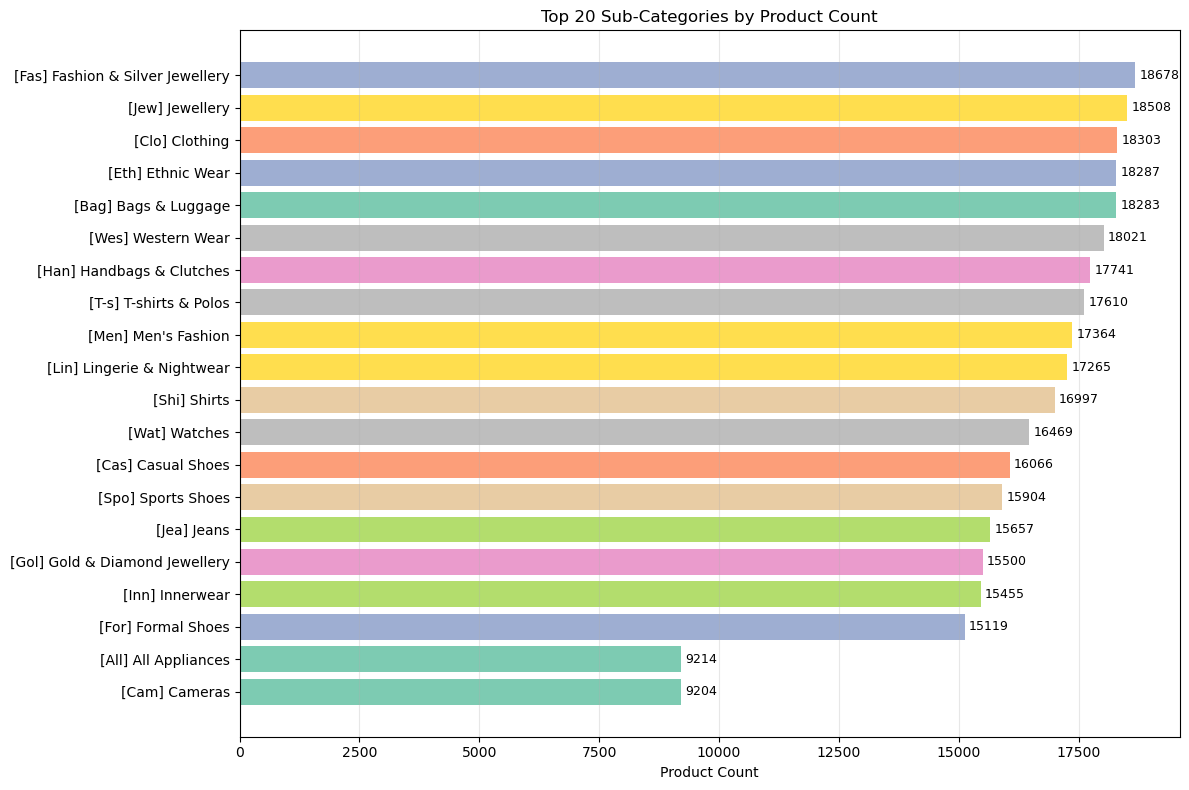

In [12]:
# Top 20 sub-categories by product count — horizontal bar chart
if "sub_category" in products.columns:
    top_subs = (
        products.filter(pl.col("sub_category").is_not_null())
        .group_by(["source_category", "sub_category"])
        .agg(
            pl.len().alias("count"),
            *([pl.col("discount_price").median().round(0).alias("median_price")]
              if "discount_price" in products.columns else []),
        )
        .sort("count", descending=True)
        .head(20)
    )

    labels = [
        f"[{row['source_category'][:3]}] {row['sub_category'][:35]}"
        for row in top_subs.iter_rows(named=True)
    ]
    counts = top_subs["count"].to_list()
    palette = plt.cm.Set2(np.linspace(0, 1, len(set(top_subs["source_category"].to_list()))))
    cat_color = {c: palette[i] for i, c in enumerate(sorted(set(top_subs["source_category"].to_list())))}
    colors = [cat_color[r] for r in top_subs["source_category"].to_list()]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(labels, counts, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
    ax.set_xlabel("Product Count")
    ax.set_title("Top 20 Sub-Categories by Product Count")
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(DATA_DIR / "amazon_subcategories.png", dpi=130)
    plt.show()


---
## Step 9 — Export clean data for the unstructured pipeline

Write the cleaned Polars DataFrame as Parquet so `02_unstructured_amazon_reviews.ipynb`
can load it directly without re-running the cleaning logic.

In [ ]:
out_path = DATA_DIR / "amazon_products_clean.parquet"
products.write_parquet(out_path)
size_mb = out_path.stat().st_size / 1e6


---
## Summary

| Step | Tool(s) | What happened |
|------|---------|---------------|
| 1 | Polars `read_csv` | Auto-discovered and loaded **all** category CSVs from `DATA_DIR`; falls back to `Amazon-Products.csv` if individual files not present |
| 2 | Polars string expressions | Cleaned prices (₹/$), ratings, review counts |
| 3 | Polars `describe`, `group_by` | EDA: row counts, null checks across all categories |
| 4 | **Polars + cuDF** (`pl.GPUEngine`) | GPU-accelerated price/rating aggregation by sub-category |
| 5 | Polars `sort` + `group_by.head` | Top-discount products per category |
| 6 | `pl.GPUEngine` benchmark | CPU vs GPU timing on aggregation |
| 7 | Polars window expressions | Wilson confidence score for rating quality |
| 8 | matplotlib | Price distribution, discount %, rating histogram, sub-category bar chart |
| 9 | Polars `write_parquet` | Exported clean data for `02_unstructured_amazon_reviews.ipynb` and the Streamlit dashboard |

**Next**: `02_unstructured_amazon_reviews.ipynb` — embed review text, run semantic search, cluster by topic.